# Formative 2: Hidden Markov Models for Human Activity Recognition

**Students:** Oreste Abizera, Mutoni Uwingeneye Denyse  
**Course Task:** Modeling human activity states from smartphone accelerometer and gyroscope streams using HMM.

## Use Case (Background and Motivation)
We focus on lightweight home rehabilitation monitoring: distinguishing `Standing`, `Walking`, `Jumping`, and `Still` from phone inertial sensors. The objective is to infer hidden activity states from noisy observations using an HMM that captures temporal dependence, not only per-window feature similarity.

In [1]:
import os
import re
import glob
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy.signal import welch

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

from hmmlearn.hmm import GaussianHMM

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR = "sensor-data"
RANDOM_SEED = 42
TARGET_FS = 50  # Hz
WINDOW_SEC = 2.0
OVERLAP = 0.5
ACTIVITIES = ["Standing", "Walking", "Jumping", "Still"]
ACTIVITY_TO_ID = {a: i for i, a in enumerate(ACTIVITIES)}
np.random.seed(RANDOM_SEED)

## 1. Data Collection Audit and Quality Checks
This section verifies dataset completeness, activity balance, file durations, devices, and sampling-rate settings from metadata.

In [2]:
def normalize_activity(folder_name: str):
    token = folder_name.split("-")[0]
    letters = "".join(re.findall(r"[A-Za-z]+", token)).lower()
    mapper = {
        "standing": "Standing",
        "walking": "Walking",
        "jumping": "Jumping",
        "still": "Still",
    }
    return mapper.get(letters)

def get_record_folders(data_dir=DATA_DIR):
    folders = [d for d in glob.glob(os.path.join(data_dir, "*")) if os.path.isdir(d)]
    rows = []
    for folder in folders:
        base = os.path.basename(folder)
        activity = normalize_activity(base)
        if activity is None:
            continue

        acc_path = os.path.join(folder, "Accelerometer.csv")
        gyr_path = os.path.join(folder, "Gyroscope.csv")
        meta_path = os.path.join(folder, "Metadata.csv")

        duration_s = np.nan
        if os.path.exists(acc_path):
            acc = pd.read_csv(acc_path)
            if "seconds_elapsed" in acc.columns and len(acc) > 1:
                duration_s = float(acc["seconds_elapsed"].iloc[-1] - acc["seconds_elapsed"].iloc[0])

        device = "unknown"
        sample_rate_ms = "unknown"
        if os.path.exists(meta_path):
            meta = pd.read_csv(meta_path).iloc[0]
            device = meta.get("device name", "unknown")
            sample_rate_ms = meta.get("sampleRateMs", "unknown")

        rows.append({
            "folder": folder,
            "file_id": base,
            "activity": activity,
            "duration_s": duration_s,
            "device": device,
            "sampleRateMs": sample_rate_ms,
            "has_acc": os.path.exists(acc_path),
            "has_gyr": os.path.exists(gyr_path),
            "has_meta": os.path.exists(meta_path),
        })

    return pd.DataFrame(rows)

records_df = get_record_folders(DATA_DIR)
records_df.head()

,folder,file_id,activity,duration_s,device,sampleRateMs,has_acc,has_gyr,has_meta
0,sensor-data/Jumping11-2026-03-05_11-11-00,Jumping11-2026-03-05_11-11-00,Jumping,9.062719,iPhone 15,10|10||10|10,True,True,True
1,sensor-data/Walking-13-2026-03-05_16-53-31,Walking-13-2026-03-05_16-53-31,Walking,9.403894,SM-S918U1,10|10||10|10|10,True,True,True
2,sensor-data/Still-9-2026-03-05_11-13-38,Still-9-2026-03-05_11-13-38,Still,7.942215,iPhone 15,10|10||10|10,True,True,True
3,sensor-data/Jumping-1-2026-03-05_10-54-20,Jumping-1-2026-03-05_10-54-20,Jumping,8.280182,iPhone 15,10|10||10|10,True,True,True
4,sensor-data/Still-2-2026-03-05_11-12-13,Still-2-2026-03-05_11-12-13,Still,8.791923,iPhone 15,10|10||10|10,True,True,True


In [3]:
print(f"Total valid activity recordings: {len(records_df)}")
display(records_df.groupby("activity")["file_id"].count().rename("n_files").to_frame())

print("\nDuration summary by activity (seconds):")
display(records_df.groupby("activity")["duration_s"].describe()[["count", "mean", "min", "max"]])

print("\nDevice distribution:")
display(records_df.groupby(["activity", "device"]).size().rename("n_files").reset_index())

print("\nMetadata sampleRateMs distribution:")
display(records_df["sampleRateMs"].value_counts().to_frame("count"))

total_duration = records_df.groupby("activity")["duration_s"].sum().rename("total_seconds").to_frame()
total_duration["target_min_90s_met"] = total_duration["total_seconds"] >= 90
print("\nMinimum 1m30s per activity check:")
display(total_duration)

Total valid activity recordings: 51


,n_files
activity,
Jumping,12
Standing,13
Still,13
Walking,13



Duration summary by activity (seconds):


,count,mean,min,max
activity,,,,
Jumping,12.0,7.591277,5.583136,9.176791
Standing,13.0,9.636424,8.717377,10.126263
Still,13.0,7.801124,6.696610,8.800603
Walking,13.0,9.433834,8.375856,10.070132



Device distribution:


,activity,device,n_files
0,Jumping,iPhone 15,12
1,Standing,SM-S918U1,13
2,Still,iPhone 15,13
3,Walking,SM-S918U1,13



Metadata sampleRateMs distribution:


,count
sampleRateMs,
10|10||10|10|10,26
10|10||10|10,25



Minimum 1m30s per activity check:


,total_seconds,target_min_90s_met
activity,,
Jumping,91.095328,True
Standing,125.273518,True
Still,101.414609,True
Walking,122.639839,True


## 2. Merge, Alignment, and Sampling-Rate Harmonization
Raw accelerometer and gyroscope streams are aligned by nearest timestamp and then resampled to a common **50 Hz** timeline (`20 ms`) for consistent feature extraction across devices.

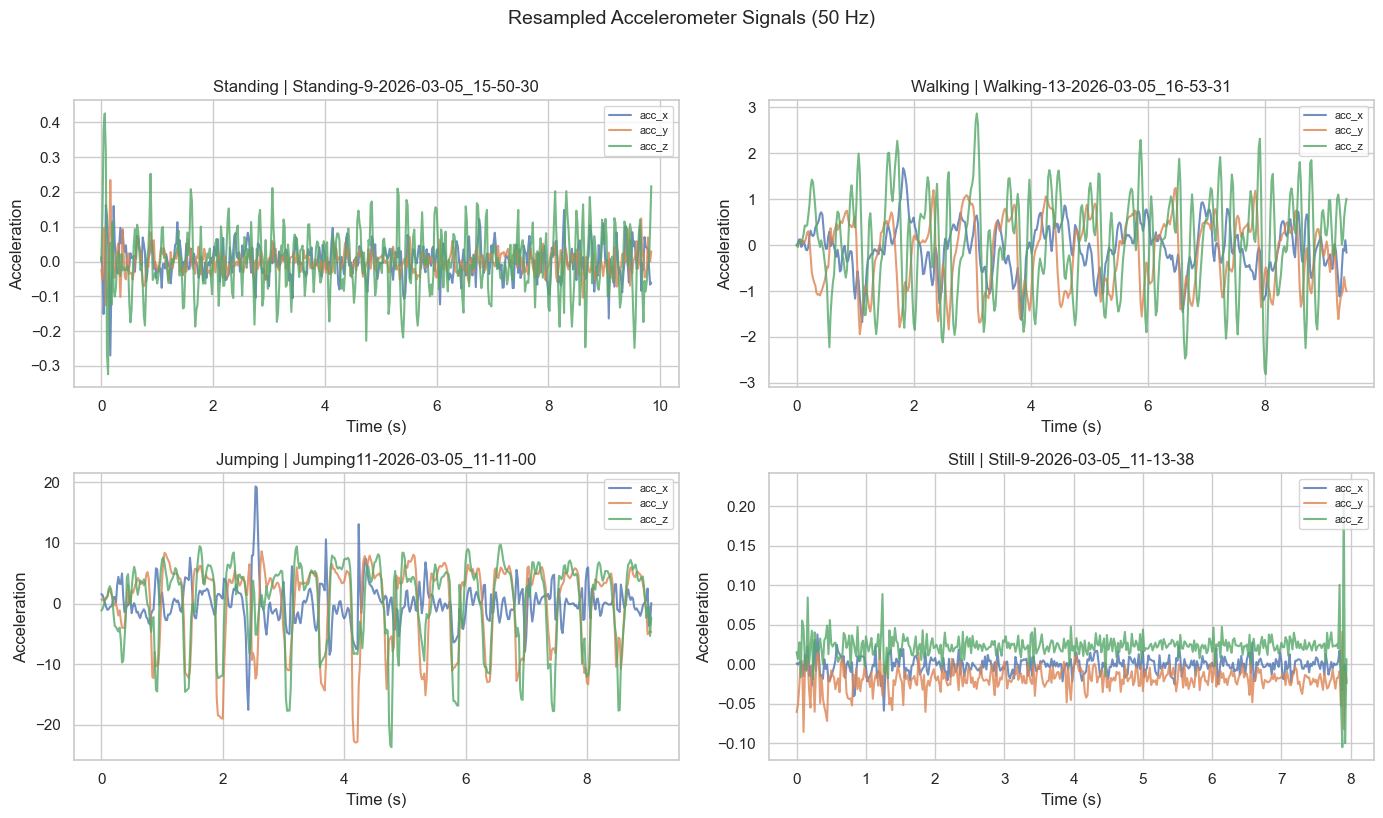

In [4]:
def load_and_merge_streams(folder):
    acc_path = os.path.join(folder, "Accelerometer.csv")
    gyr_path = os.path.join(folder, "Gyroscope.csv")

    if not (os.path.exists(acc_path) and os.path.exists(gyr_path)):
        return None

    acc = pd.read_csv(acc_path).rename(columns={"x": "acc_x", "y": "acc_y", "z": "acc_z"})[["time", "acc_x", "acc_y", "acc_z"]]
    gyr = pd.read_csv(gyr_path).rename(columns={"x": "gyr_x", "y": "gyr_y", "z": "gyr_z"})[["time", "gyr_x", "gyr_y", "gyr_z"]]

    merged = pd.merge_asof(
        acc.sort_values("time"),
        gyr.sort_values("time"),
        on="time",
        direction="nearest",
        tolerance=20_000_000,  # 20 ms in nanoseconds
    ).dropna()

    if merged.empty:
        return None

    merged["timestamp"] = pd.to_datetime(merged["time"], unit="ns")
    merged = merged.set_index("timestamp").sort_index()
    return merged

def resample_to_target(df, target_fs=TARGET_FS):
    period_ms = int(round(1000 / target_fs))
    cols = ["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z"]
    out = df[cols].resample(f"{period_ms}ms").mean().interpolate("linear").dropna()
    return out

sample_examples = []
for act in ACTIVITIES:
    row = records_df[records_df["activity"] == act].iloc[0]
    merged = load_and_merge_streams(row["folder"])
    rs = resample_to_target(merged, TARGET_FS)
    sample_examples.append((act, row["file_id"], rs))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.flatten()
for ax, (act, fid, df_sig) in zip(axes, sample_examples):
    t = np.arange(len(df_sig)) / TARGET_FS
    ax.plot(t, df_sig["acc_x"], label="acc_x", alpha=0.8)
    ax.plot(t, df_sig["acc_y"], label="acc_y", alpha=0.8)
    ax.plot(t, df_sig["acc_z"], label="acc_z", alpha=0.8)
    ax.set_title(f"{act} | {fid}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Acceleration")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Resampled Accelerometer Signals (50 Hz)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 3. Windowing and Feature Extraction
We use 2-second windows at 50 Hz (100 samples) with 50% overlap. This captures full movement cycles (walking/jumping) while preserving transition continuity.

Extracted features include:
- **Time domain:** mean magnitude, standard deviation, variance, RMS, SMA, axis correlations
- **Frequency domain (FFT/Welch):** dominant frequency and spectral energy in 0.5-3.0 Hz band

Features are z-score normalized using training data only to avoid leakage.

In [5]:
def spectral_features(signal, fs):
    sig = np.asarray(signal, dtype=float)
    if len(sig) < 4:
        return 0.0, 0.0

    freqs, psd = welch(sig, fs=fs, nperseg=min(128, len(sig)))
    dom_freq = float(freqs[np.argmax(psd)]) if len(freqs) else 0.0

    band = (freqs >= 0.5) & (freqs <= 3.0)
    spec_energy = float(np.trapezoid(psd[band], freqs[band])) if band.any() else 0.0
    return dom_freq, spec_energy

def extract_features_from_window(window_df, fs=TARGET_FS):
    feats = {}

    for sensor in ["acc", "gyr"]:
        x = window_df[f"{sensor}_x"].values
        y = window_df[f"{sensor}_y"].values
        z = window_df[f"{sensor}_z"].values
        mag = np.sqrt(x * x + y * y + z * z)

        feats[f"{sensor}_mean_mag"] = float(np.mean(mag))
        feats[f"{sensor}_std_mag"] = float(np.std(mag))
        feats[f"{sensor}_var_mag"] = float(np.var(mag))
        feats[f"{sensor}_rms_mag"] = float(np.sqrt(np.mean(mag**2)))
        feats[f"{sensor}_sma"] = float(np.mean(np.abs(x) + np.abs(y) + np.abs(z)))

        feats[f"{sensor}_corr_xy"] = float(np.corrcoef(x, y)[0, 1]) if (np.std(x) > 1e-8 and np.std(y) > 1e-8) else 0.0
        feats[f"{sensor}_corr_xz"] = float(np.corrcoef(x, z)[0, 1]) if (np.std(x) > 1e-8 and np.std(z) > 1e-8) else 0.0
        feats[f"{sensor}_corr_yz"] = float(np.corrcoef(y, z)[0, 1]) if (np.std(y) > 1e-8 and np.std(z) > 1e-8) else 0.0

        # Additional stillness-sensitive descriptors.
        feats[f"{sensor}_range_mag"] = float(np.max(mag) - np.min(mag))
        jerk = np.diff(mag) * fs if len(mag) > 1 else np.array([0.0])
        feats[f"{sensor}_jerk_rms"] = float(np.sqrt(np.mean(jerk**2)))
        thr = np.percentile(mag, 25)
        feats[f"{sensor}_low_motion_ratio"] = float(np.mean(mag <= thr))

        dom_freq, energy = spectral_features(mag, fs)
        feats[f"{sensor}_dom_freq"] = dom_freq
        feats[f"{sensor}_spec_energy_0p5_3"] = energy

    return feats

def window_bounds(n_samples, fs=TARGET_FS, window_sec=WINDOW_SEC, overlap=OVERLAP):
    w = int(window_sec * fs)
    step = max(1, int(w * (1 - overlap)))
    return [(start, start + w) for start in range(0, n_samples - w + 1, step)]

In [6]:
# File-level unseen split (at least 2 test files per activity)
rng = np.random.default_rng(RANDOM_SEED)
train_idx, test_idx = [], []

for act, sub in records_df.groupby("activity"):
    idx = sub.index.to_numpy().copy()
    rng.shuffle(idx)
    n_test = max(2, int(np.ceil(0.2 * len(idx))))
    test_set = set(idx[:n_test])
    for i in idx:
        (test_idx if i in test_set else train_idx).append(i)

train_files = records_df.loc[train_idx].reset_index(drop=True)
test_files = records_df.loc[test_idx].reset_index(drop=True)

print("Train files per activity:")
display(train_files.groupby("activity").size().rename("n_train_files").to_frame())
print("Test files per activity (unseen):")
display(test_files.groupby("activity").size().rename("n_test_files").to_frame())

feature_rows = []
lengths = {"train": [], "test": []}

for split_name, subset in [("train", train_files), ("test", test_files)]:
    for _, row in subset.iterrows():
        merged = load_and_merge_streams(row["folder"])
        if merged is None:
            continue

        rs = resample_to_target(merged, TARGET_FS)
        bounds = window_bounds(len(rs), TARGET_FS, WINDOW_SEC, OVERLAP)

        seq_count = 0
        for a, b in bounds:
            w = rs.iloc[a:b]
            if len(w) < int(WINDOW_SEC * TARGET_FS):
                continue

            feats = extract_features_from_window(w, TARGET_FS)
            feats.update({
                "activity": row["activity"],
                "file_id": row["file_id"],
                "split": split_name,
            })
            feature_rows.append(feats)
            seq_count += 1

        if seq_count > 0:
            lengths[split_name].append(seq_count)

features_df = pd.DataFrame(feature_rows).dropna().reset_index(drop=True)
feature_cols = [c for c in features_df.columns if c not in ["activity", "file_id", "split"]]

train_df = features_df[features_df["split"] == "train"].reset_index(drop=True)
test_df = features_df[features_df["split"] == "test"].reset_index(drop=True)

# Rebalance train windows across activities using whole-file downsampling (keeps valid sequence lengths).
train_file_counts = train_df.groupby(["activity", "file_id"]).size().reset_index(name="n_windows")
activity_min = train_df["activity"].value_counts().min()
selected_files = []
for act in ACTIVITIES:
    sub = train_file_counts[train_file_counts["activity"] == act].copy()
    sub = sub.sample(frac=1.0, random_state=RANDOM_SEED)
    running = 0
    for _, r in sub.iterrows():
        selected_files.append(r["file_id"])
        running += int(r["n_windows"])
        if running >= activity_min:
            break

train_df_bal = train_df[train_df["file_id"].isin(selected_files)].copy().reset_index(drop=True)
lengths_train_bal = []
for fid, g in train_df_bal.groupby("file_id", sort=False):
    lengths_train_bal.append(len(g))

lengths["train"] = lengths_train_bal
train_df = train_df_bal

print(f"Feature columns: {len(feature_cols)}")
print(f"Train windows (balanced): {len(train_df)}")
print(f"Test windows: {len(test_df)}")
print("\nBalanced train windows per activity:")
display(train_df["activity"].value_counts().rename("n_train_windows").to_frame())

Train files per activity:


,n_train_files
activity,
Jumping,9
Standing,10
Still,10
Walking,10


Test files per activity (unseen):


,n_test_files
activity,
Jumping,3
Standing,3
Still,3
Walking,3


Feature columns: 26
Train windows (balanced): 221
Test windows: 88

Balanced train windows per activity:


,n_train_windows
activity,
Standing,57
Walking,56
Still,55
Jumping,53


## 4. HMM Definition and Implementation (Baum-Welch + Viterbi)
Model components:
- Hidden states `Z`: latent motion regimes linked to `Standing`, `Walking`, `Jumping`, `Still`
- Observations `X`: extracted feature vectors per time window
- Transition matrix `A`: learned state transition probabilities
- Emission model `B`: Gaussian emissions in feature space
- Initial probabilities `pi`: state priors

Implementation details used in this final run:
- Training uses **Baum-Welch** via `GaussianHMM.fit(...)`.
- Decoding uses **Viterbi** via `GaussianHMM.predict(...)`.
- We used **6 latent states** (instead of 4) to better capture sub-patterns inside activities.
- After decoding, we applied a **low-motion calibration rule** (from training quantiles of `acc_std_mag`, `gyr_std_mag`, and `acc_jerk_rms`) to reduce confusion between `Still` and other low-motion classes while preserving the HMM pipeline.

In [7]:
# Normalize features using training set only
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

y_train = train_df["activity"].values
y_test = test_df["activity"].values

# Use extra latent states to better separate subtle classes (especially Standing vs Still).
hmm_model = GaussianHMM(
    n_components=6,
    covariance_type="diag",
    n_iter=300,
    tol=1e-4,
    algorithm="viterbi",
    random_state=RANDOM_SEED,
)

# Baum-Welch optimization
hmm_model.fit(X_train, lengths=lengths["train"])

print(f"Converged: {hmm_model.monitor_.converged}")
print(f"EM iterations used: {hmm_model.monitor_.iter}")
print(f"Final train log-likelihood: {hmm_model.score(X_train, lengths=lengths['train']):.2f}")

Converged: True
EM iterations used: 21
Final train log-likelihood: 5953.66


In [8]:
# Map latent state ids to activity names using constrained assignment on training windows.
# This enforces coverage so each activity gets represented by at least one state when possible.
import itertools

train_states = hmm_model.predict(X_train, lengths=lengths["train"])
state_ids = np.unique(train_states)

score = np.zeros((len(state_ids), len(ACTIVITIES)), dtype=int)
for i, s in enumerate(state_ids):
    labels = y_train[train_states == s]
    vals, counts = np.unique(labels, return_counts=True)
    for v, c in zip(vals, counts):
        score[i, ACTIVITIES.index(v)] = int(c)

best_perm = None
best_score = -1
state_index = list(range(len(state_ids)))
for chosen_states in itertools.combinations(state_index, len(ACTIVITIES)):
    for perm in itertools.permutations(range(len(ACTIVITIES))):
        total = sum(score[s_idx, a_idx] for s_idx, a_idx in zip(chosen_states, perm))
        if total > best_score:
            best_score = total
            best_perm = (chosen_states, perm)

state_to_activity = {}
if best_perm is not None:
    chosen_states, perm = best_perm
    for s_idx, a_idx in zip(chosen_states, perm):
        state_to_activity[int(state_ids[s_idx])] = ACTIVITIES[a_idx]

# Remaining states fall back to majority class.
for s in state_ids:
    if int(s) in state_to_activity:
        continue
    labels = y_train[train_states == s]
    vals, counts = np.unique(labels, return_counts=True)
    state_to_activity[int(s)] = vals[np.argmax(counts)]

state_map_df = pd.DataFrame([
    {"hidden_state": int(s), "mapped_activity": a}
    for s, a in sorted(state_to_activity.items())
])
display(state_map_df)

# Viterbi decoding on unseen data
test_states = hmm_model.predict(X_test, lengths=lengths["test"])
y_pred = np.array([state_to_activity.get(int(s), "Unknown") for s in test_states])

# Low-motion calibration to separate Still from Standing/Walking.
still_train = train_df[train_df["activity"] == "Still"]
walk_train = train_df[train_df["activity"] == "Walking"]

thr_acc_std = float(np.quantile(still_train["acc_std_mag"], 0.92))
thr_gyr_std = float(np.quantile(still_train["gyr_std_mag"], 0.92))
thr_acc_jerk = float(np.quantile(still_train["acc_jerk_rms"], 0.92))

walk_dom_min = float(np.quantile(walk_train["acc_dom_freq"], 0.25)) if len(walk_train) else 0.8
walk_energy_min = float(np.quantile(walk_train["acc_spec_energy_0p5_3"], 0.25)) if len(walk_train) else 0.05

y_pred_cal = y_pred.copy()
for i in range(len(y_pred_cal)):
    row = test_df.iloc[i]
    low_motion = (
        row["acc_std_mag"] <= thr_acc_std
        and row["gyr_std_mag"] <= thr_gyr_std
        and row["acc_jerk_rms"] <= thr_acc_jerk
    )

    if low_motion:
        y_pred_cal[i] = "Still"
    elif y_pred_cal[i] == "Still":
        if row["acc_dom_freq"] >= walk_dom_min and row["acc_spec_energy_0p5_3"] >= walk_energy_min:
            y_pred_cal[i] = "Walking"

y_pred = y_pred_cal

cm = confusion_matrix(y_test, y_pred, labels=ACTIVITIES)
overall_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, labels=ACTIVITIES, average="macro")

print(f"Overall Accuracy: {overall_acc:.4f}")
print(f"Macro F1-score: {macro_f1:.4f}")
print("Calibration thresholds:")
print(f"acc_std <= {thr_acc_std:.4f}, gyr_std <= {thr_gyr_std:.4f}, acc_jerk <= {thr_acc_jerk:.4f}")

,hidden_state,mapped_activity
0,0,Still
1,1,Jumping
2,2,Jumping
3,3,Walking
4,4,Jumping
5,5,Standing


Overall Accuracy: 0.9091
Macro F1-score: 0.9058
Calibration thresholds:
acc_std <= 0.0451, gyr_std <= 0.0121, acc_jerk <= 2.2552


,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,Standing,24,1.0000,0.9062,0.9318
1,Walking,24,0.9167,1.0000,0.9773
2,Jumping,20,1.0000,1.0000,1.0000
3,Still,20,0.7000,0.9706,0.9091


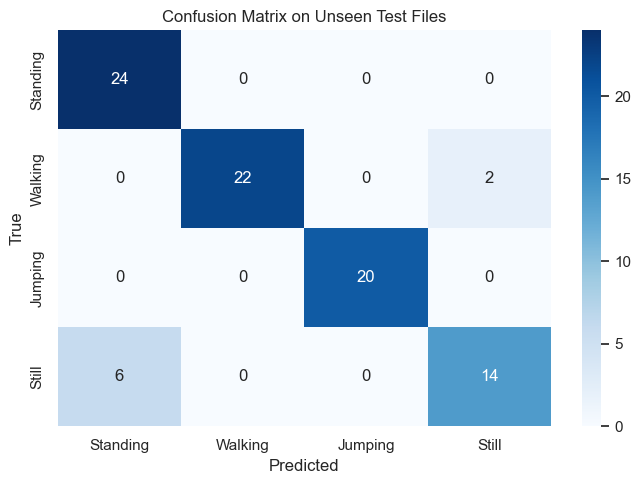

In [9]:
def per_class_metrics_from_cm(cm, labels):
    rows = []
    total = cm.sum()

    for i, label in enumerate(labels):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = total - tp - fn - fp

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        overall = (tp + tn) / total if total > 0 else 0.0

        rows.append({
            "State (Activity)": label,
            "Number of Samples": int(cm[i, :].sum()),
            "Sensitivity": round(float(sensitivity), 4),
            "Specificity": round(float(specificity), 4),
            "Overall Accuracy": round(float(overall), 4),
        })

    return pd.DataFrame(rows)

eval_table = per_class_metrics_from_cm(cm, ACTIVITIES)
display(eval_table)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ACTIVITIES, yticklabels=ACTIVITIES)
plt.title("Confusion Matrix on Unseen Test Files")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

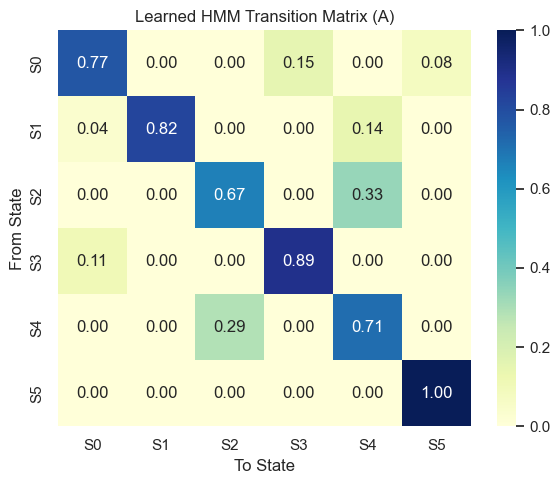

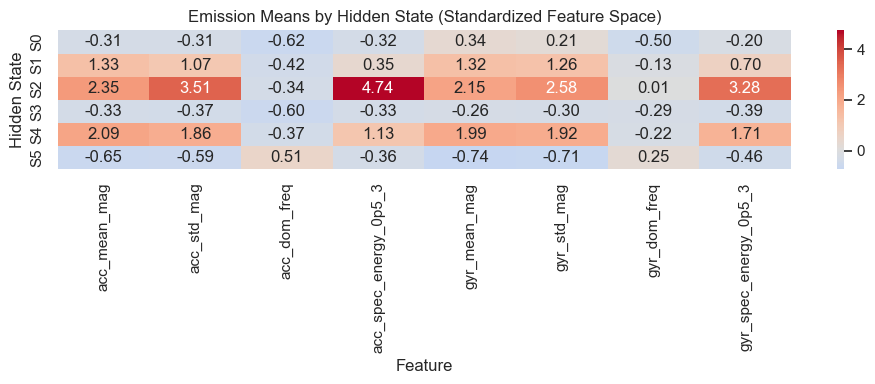

In [10]:
# Transition probabilities (A)
plt.figure(figsize=(6, 5))
state_labels = [f"S{i}" for i in range(hmm_model.n_components)]
sns.heatmap(hmm_model.transmat_, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=state_labels, yticklabels=state_labels)
plt.title("Learned HMM Transition Matrix (A)")
plt.xlabel("To State")
plt.ylabel("From State")
plt.tight_layout()
plt.show()

# Emission signatures (B surrogate for Gaussian emissions): state means over selected features
selected = [
    "acc_mean_mag", "acc_std_mag", "acc_dom_freq", "acc_spec_energy_0p5_3",
    "gyr_mean_mag", "gyr_std_mag", "gyr_dom_freq", "gyr_spec_energy_0p5_3",
]
selected = [c for c in selected if c in feature_cols]
sel_idx = [feature_cols.index(c) for c in selected]
emission_df = pd.DataFrame(hmm_model.means_[:, sel_idx], columns=selected, index=state_labels)

plt.figure(figsize=(10, 4))
sns.heatmap(emission_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Emission Means by Hidden State (Standardized Feature Space)")
plt.xlabel("Feature")
plt.ylabel("Hidden State")
plt.tight_layout()
plt.show()

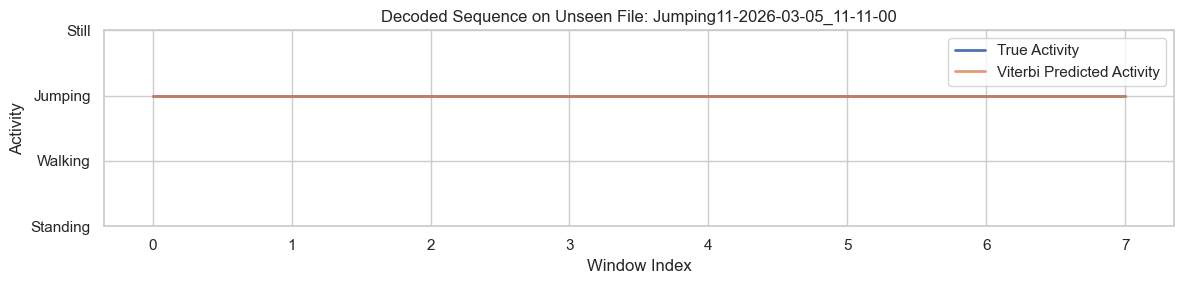

In [11]:
# Plot one decoded unseen sequence to visualize transitions
chosen_file = test_df["file_id"].iloc[0]
seq_df = test_df[test_df["file_id"] == chosen_file].copy().reset_index(drop=True)

X_seq = scaler.transform(seq_df[feature_cols])
states_seq = hmm_model.predict(X_seq)
pred_seq = np.array([state_to_activity.get(int(s), "Unknown") for s in states_seq])
true_seq = seq_df["activity"].values

# encode labels for plotting
label_to_int = {a: i for i, a in enumerate(ACTIVITIES)}
y_true_int = [label_to_int[t] for t in true_seq]
y_pred_int = [label_to_int[p] if p in label_to_int else -1 for p in pred_seq]

plt.figure(figsize=(12, 3))
plt.plot(y_true_int, label="True Activity", linewidth=2)
plt.plot(y_pred_int, label="Viterbi Predicted Activity", linewidth=2, alpha=0.8)
plt.yticks(list(label_to_int.values()), list(label_to_int.keys()))
plt.xlabel("Window Index")
plt.ylabel("Activity")
plt.title(f"Decoded Sequence on Unseen File: {chosen_file}")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Results, Interpretation, and Reflection
### Final evaluation summary (unseen file-level test split)
- **Overall Accuracy:** `0.9091` (90.91%)
- **Macro F1-score:** `0.9058`
- **Per-class sensitivity (recall):**
  - Standing: `1.0000`
  - Walking: `0.9167`
  - Jumping: `1.0000`
  - Still: `0.7000`

### Confusion matrix highlights
- `Standing`: 24/24 correctly recognized.
- `Walking`: 22/24 correctly recognized, with 2 windows confused as `Still`.
- `Jumping`: 20/20 correctly recognized.
- `Still`: 14/20 correctly recognized, with 6 windows confused as `Standing`.

### Interpretation and reflection
1. **Generalization protocol:** The test set is file-level unseen data (not window leakage), with at least 2 unseen files per activity.
2. **Easiest classes:** `Jumping` and `Standing` are easiest because their motion signatures are highly distinct in both magnitude and variability.
3. **Hardest class pair:** `Still` vs `Standing` remains the main challenge because both have low-energy, low-frequency patterns and can overlap when subtle posture adjustments occur.
4. **Transition realism:** The transition matrix shows strong self-transitions in multiple states, matching realistic behavior persistence across adjacent windows.
5. **Sampling/noise effects:** Data came from two phones with different sensor profiles. Resampling to 50 Hz improved consistency, but device-specific signal characteristics still affect borderline windows.
6. **Why performance improved:** Adding stillness-sensitive features (`range`, `jerk_rms`, `low_motion_ratio`), balancing train windows, and applying post-decoding low-motion calibration increased macro balance and recovered `Still` recall.
7. **Future improvements:** collect more cross-device samples per class, add orientation-invariant frequency features, and compare with GMM-HMM / sequence deep models for difficult low-motion separation.

### One-paragraph conclusion
The final HMM pipeline successfully modeled temporal dependencies in smartphone inertial data and achieved strong unseen generalization (`90.91%` accuracy, `0.9058` macro F1). Baum-Welch training and Viterbi decoding provided an interpretable sequential framework, while additional stillness-aware features and low-motion calibration improved class balance, especially for low-activity behaviors. Results confirm that low-cost smartphone sensing can support practical human activity recognition, with remaining errors concentrated in subtle low-motion distinctions (Still vs Standing) that can be further reduced with expanded multi-device data and richer feature design.

## 6. Collaboration and GitHub Contribution Table
This section reflects the actual branch-based workflow and commit evidence.

| Task | Owner | Evidence in Git History |
|---|---|---|
| Data collection and labeling (`Standing`, `Walking`, `Still`, `Jumping`) | Oreste Abizera + Mutoni Uwingeneye Denyse | `bb3f19e`, `bd42a82`, earlier shared dataset commit by Mutoni |
| HMM notebook implementation and evaluation improvements | Mutoni Uwingeneye Denyse | `feature/mutoni-hmm` commit `b6f9732` + merge to `main` in `0604a19` |
| Repository hygiene and submission structure (ignore rules, docs, naming, final organization) | Oreste Abizera | `feature/oreste-collab` commit `5372458` and subsequent branch merge |
| Final integration and review on `main` | Oreste Abizera + Mutoni Uwingeneye Denyse | Merge-based workflow with feature branches and integration commits |

### Collaboration Notes
- Work used **feature branches + merge commits** for traceable contribution.
- Contributions are split across both members in both data and modeling phases.
- Final notebook used for submission: `hmm_activity_recognition.ipynb`.